# Generative ML

In [67]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


**Setup**: Please follow the steps given below
- Download the MINST handwritten digits dataset from https://www.kaggle.com/datasets/hojjatk/mnist-dataset/data and extract its contents to a directory named "mnist"
- Please ensure that the cs771 directory has the helper modules plotData and utils
- Please ensure that the mnist directory, the cs771 directory and this notebook, all have the same parent directory

In [68]:
import numpy as np
from numpy import random as rand
from numpy import linalg as lin
import random
from cs771 import plotData as pd
from cs771 import utils
import struct
from array import array
from os.path import join
import matplotlib.pyplot as plt

MNIST dataset reader courtesy Hojjat Khodabakhsh
https://www.kaggle.com/code/hojjatk/read-mnist-dataset

In [69]:
#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test) 

In [70]:
#
# Set file paths based on added MNIST Datasets
#
input_path = 'mnist/'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

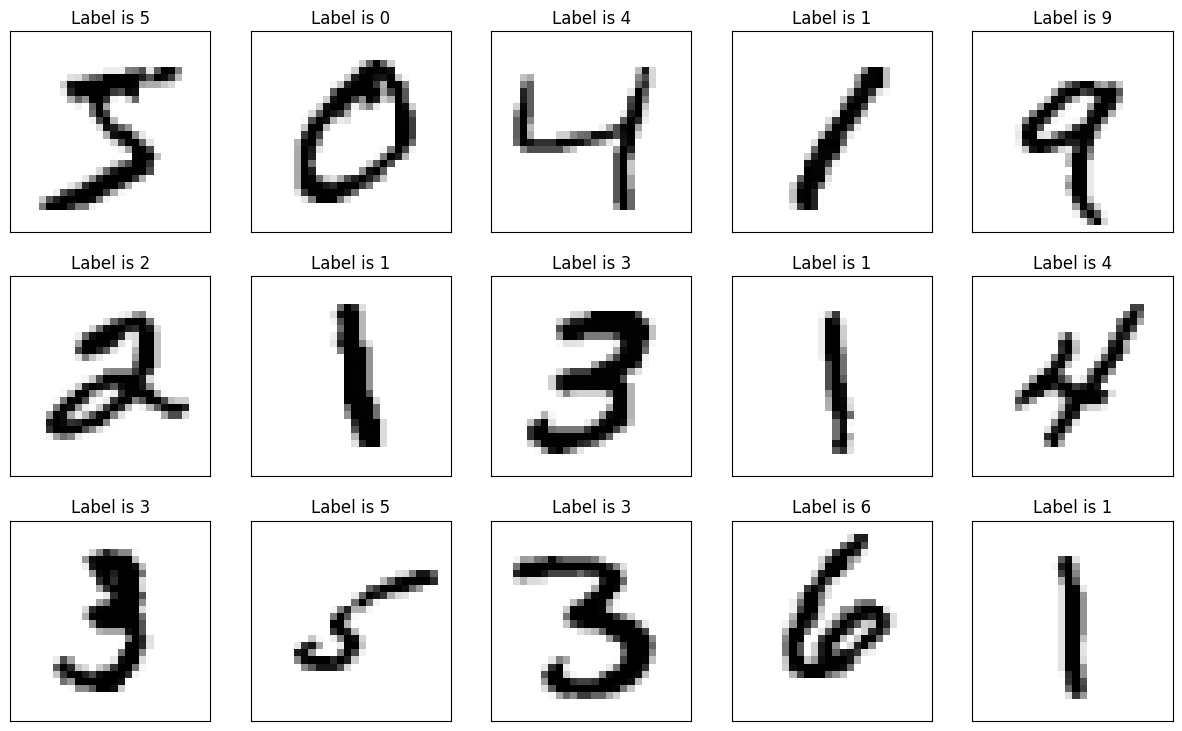

In [71]:
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
((XTrain, yTrain), (XTest, yTest)) = mnist_dataloader.load_data()
yTrain = np.array( yTrain )
yTest = np.array( yTest )

tmp = np.zeros( ( len( XTrain ), 28, 28 ) )
for i in range( len( XTrain )):
    tmp[ i, : ] = np.concatenate( XTrain[i] ).reshape( ( 28, 28 ) )
XTrain = tmp

tmp = np.zeros( ( len( XTest ), 28, 28 ) )
for i in range( len( XTest )):
    tmp[ i, : ] = np.concatenate( XTest[i] ).reshape( ( 28, 28 ) )
XTest = tmp

# How many training images do we have?
n = XTrain.shape[0]

# What is the shape of these images?
imShape = XTrain.shape[1:]

# Normalize data coordinates otherwise numbers in later calculations might explode
XTrain = XTrain/256

numRows = 3
numCols = 5

# Show the first 15 images in the dataset
fig, axs = pd.getFigList( numRows, numCols )
labels = [ "Label is %s" % yTrain[i] for i in range( numRows * numCols ) ]
pd.showImagesNoAxes( axs, XTrain[ :numRows*numCols ], numRows, numCols, labelList = labels )

**Creating a subdataset**: to make the generative learning problem simpler, let us create a smaller version of this dataset with just the images of digits 0 and 4 in the training set.

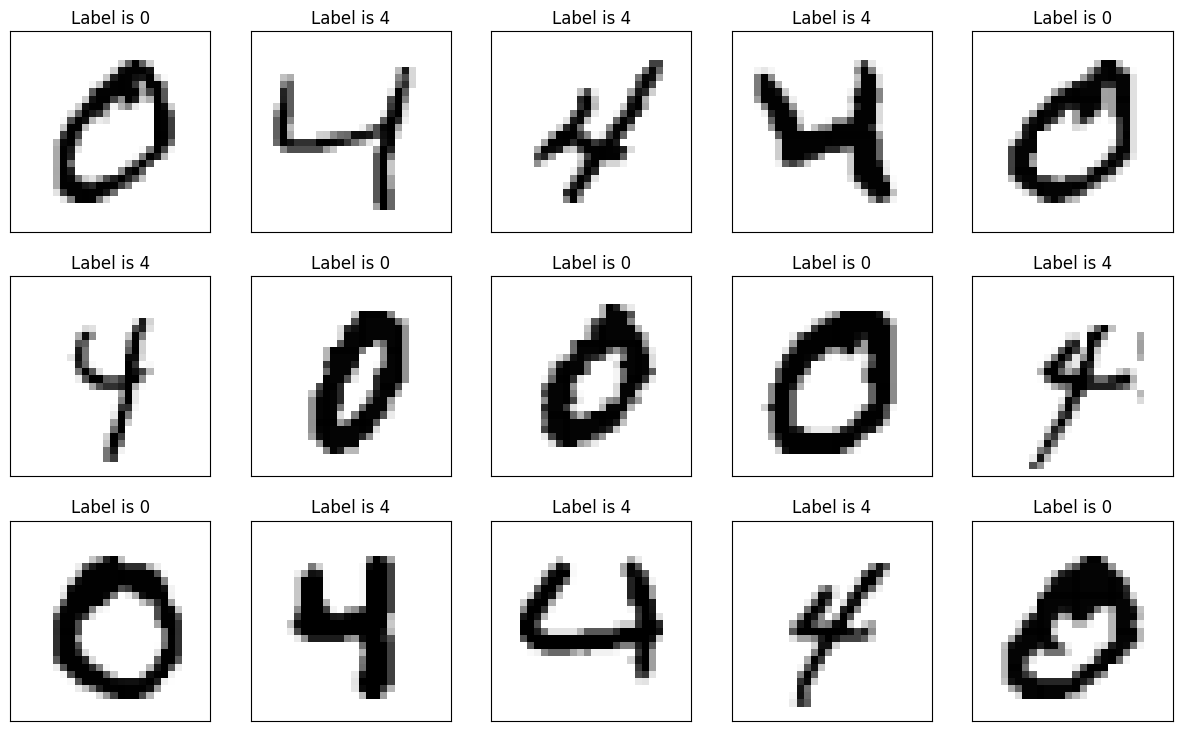

In [72]:
def getDataSubset( labels ):
    subset = np.isin( yTrain, labels )
    return (XTrain[subset][:][:], yTrain[subset])

labels = np.array( [0,4] )
(X,y) = getDataSubset( labels )

# Flatten images for sake of convenience even though it is time consuming and not essential at all
n = X.shape[0]
d = np.prod( X.shape[1:] )
X = X.reshape( n, d )

# Display the first few images of this subset dataset
fig2, axs2 = pd.getFigList( numRows, numCols )
labels = [ "Label is %s" % y[i] for i in range( numRows * numCols ) ]
pd.showImagesNoAxes( axs2, X[ :numRows*numCols ], numRows, numCols, resize = True, imShape = imShape, labelList = labels )

**Getting started**: let us start by fitting a single standard Gaussian as a generative model to our toy dataset of 0 and 4 images. We will see that this does not produce very good results at all. The mean image seems to be a ghostly superimposition of a 0 and a 4 which makes sense given the dataset contains 0s and 4s. The covariance structure is not getting learnt here at all (we are using the identity matrix as covaraiance) and the images generated out of this generative model turn out to be less than useful. Learning the structure of the covariance (and higher moments as well if possible) is vital in generative models.

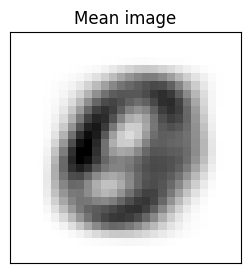

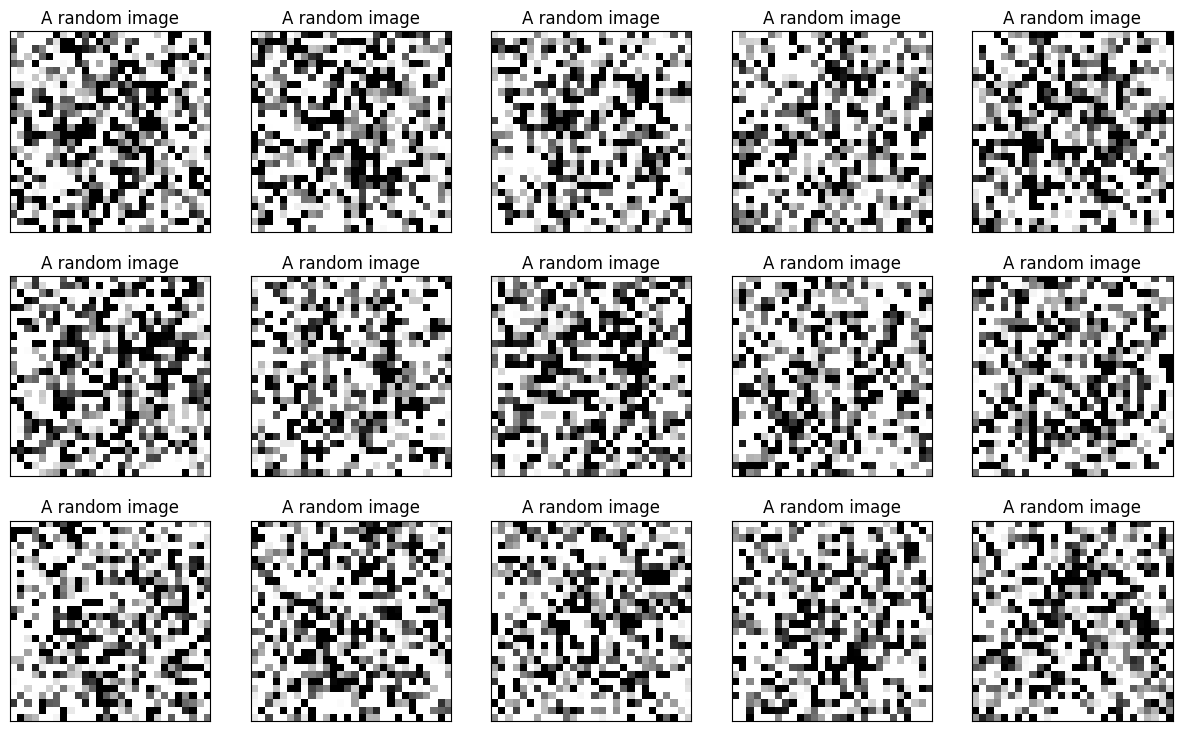

In [73]:
def fitSingleStandardGaussian( X ):
    return np.mean( X, axis = 0 )

def truncatePixels( X, low = 0, high = 1 ):
    X[X < low] = low
    X[X > high] = high
    return X

# Fit a standard Gaussian to the 0,4 dataset using an MLE
mu = fitSingleStandardGaussian( X )
fig3, axs3 = pd.getFigList( 1, 1 )
labels = [ "Mean image" ]
pd.showImagesNoAxes( axs3, mu[ np.newaxis, : ], 1, 1, resize = True, imShape = imShape, labelList = labels )

# Display a few samples taken from this distribution -- we will find these to be extremely noisy
fig4, axs4 = pd.getFigList( numRows, numCols )
labels = [ "A random image" for i in range( numRows * numCols ) ]
randSamples = rand.multivariate_normal( mu, np.identity(d), size = numRows * numCols, check_valid = "raise" )
randSamples = truncatePixels(randSamples)
pd.showImagesNoAxes( axs4, randSamples, numRows, numCols, resize = True, imShape = imShape, labelList = labels )

**The limits of a single Gaussian**: Let us learn a proper Gaussian now with both the mean and covariance getting learnt. The mean is the same as before but the crucial difference is that the covariance is getting learnt now. Notice the significant improvement in the quality of the images generated from this generative model. Although still far from satisfactory, the images at least show some semblance of 0 and 4 shapes haphazardly placed on top of each other. Learning the covariance structure properly itself caused this huge improvement.

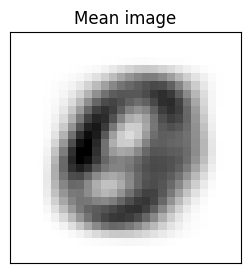

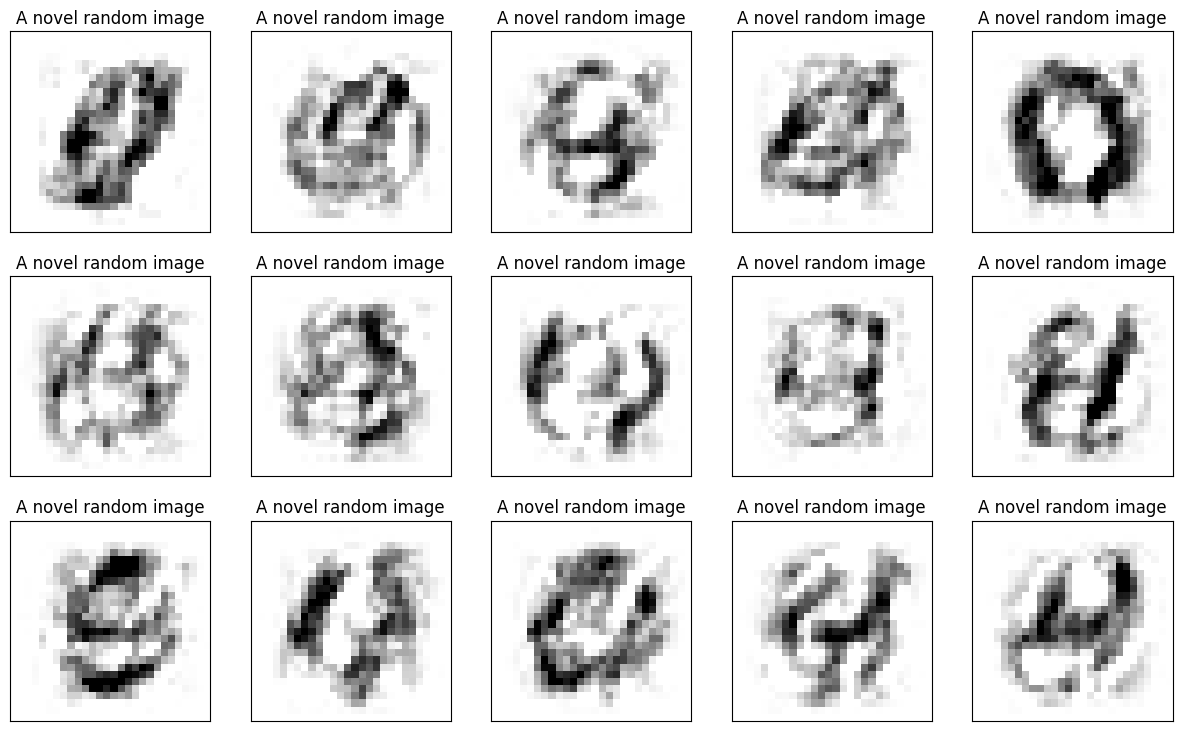

In [74]:
def fitSingleGaussian( X ):
    n = X.shape[0]
    d = np.prod( X.shape[1:] )
    X = X.reshape( n, d )
    mu = np.mean( X, axis = 0 )
    Xcent = X - mu
    cov = 1/n*(Xcent.T).dot(Xcent)
    return (mu, cov)

# Fit a general Gaussian this time to the same dataset
(mu, cov) = fitSingleGaussian( X )

fig5, axs5 = pd.getFigList( 1, 1 )
labels = [ "Mean image" ]
pd.showImagesNoAxes( axs5, mu[ np.newaxis, : ], 1, 1, resize = True, imShape = imShape, labelList = labels )

# The quality of samples is a bit better due to use of a general covariance matrix but not much better
fig6, axs6 = pd.getFigList( numRows, numCols )
labels = [ "A novel random image" for i in range( numRows * numCols ) ]
randSamples = rand.multivariate_normal( mu, cov, size = numRows * numCols, check_valid = "raise" )
randSamples = truncatePixels( randSamples )
pd.showImagesNoAxes( axs6, randSamples, numRows, numCols, resize = True, imShape = imShape, labelList = labels )

**A mixture of Gaussians**: since we know that our toy dataset contains a bunch of 0s and 4s whose appearances differ significantly, it is not surprising that a single Gaussian was unable to capture the diversity in the dataset. Let us now fit a mixture of Gaussians to this dataset. We need at least 2 components in this mixture (i.e. at least 2 Gaussians) but it is better to use slightly more e.g. 4 or more since even within a digit, there may be variations in writing style e.g. the digit 4 written upright vs written slanted.

Note that we are assuming that we do not have the labels of the imags in our training set i.e. we do not know which images are labeled 0 and which are labeled 4. This means that we would have to model this as a latent variable and use the EM algorithm to fit the mixture of Gaussians. Even if we had known the labels of the images, we would have still required the EM algorithm if, for example, we want to model the 4s using 3 components to account for variations of style etc. Since the images surely do not come labeled whether they are upright or slanted, a latent variable will be required to model this information.

**Number of Components**: Notice the significantly better samples generated by this mixture model. The samples are very realistic, diverse, yet are novel, i.e. these were never seen in training set. The quality of the samples would generally go up as the number of mixture components goes up, but if the number of components gets very large, then the method would start suffering since not only would it become slow, the number of data points per component would also fall and each component would get estimated not very well. The number of components in the mixture is a hyperparameter that needs to be tuned carefully. Too small and diversity would not be captured, too large and estimation and speed would suffer.

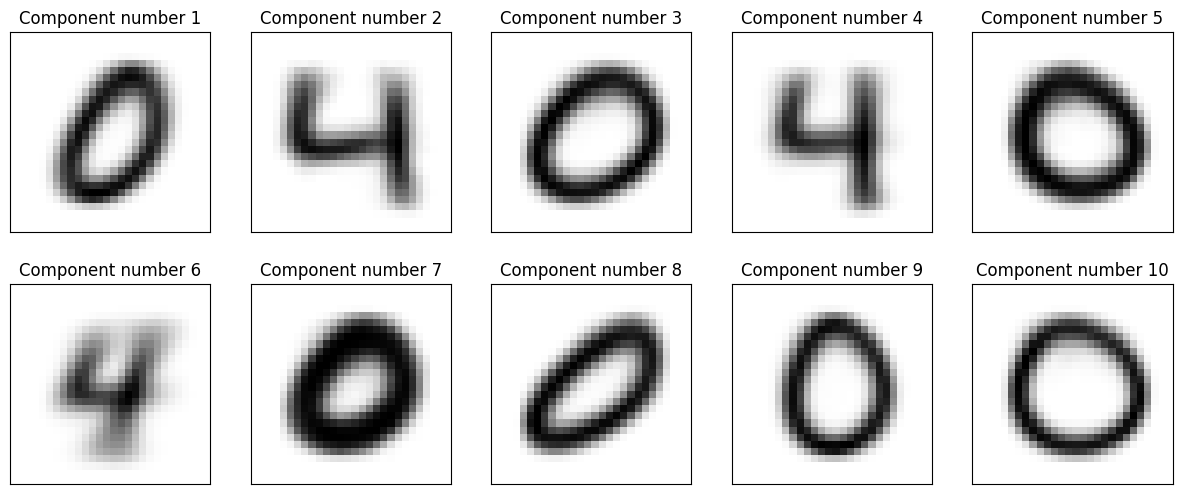

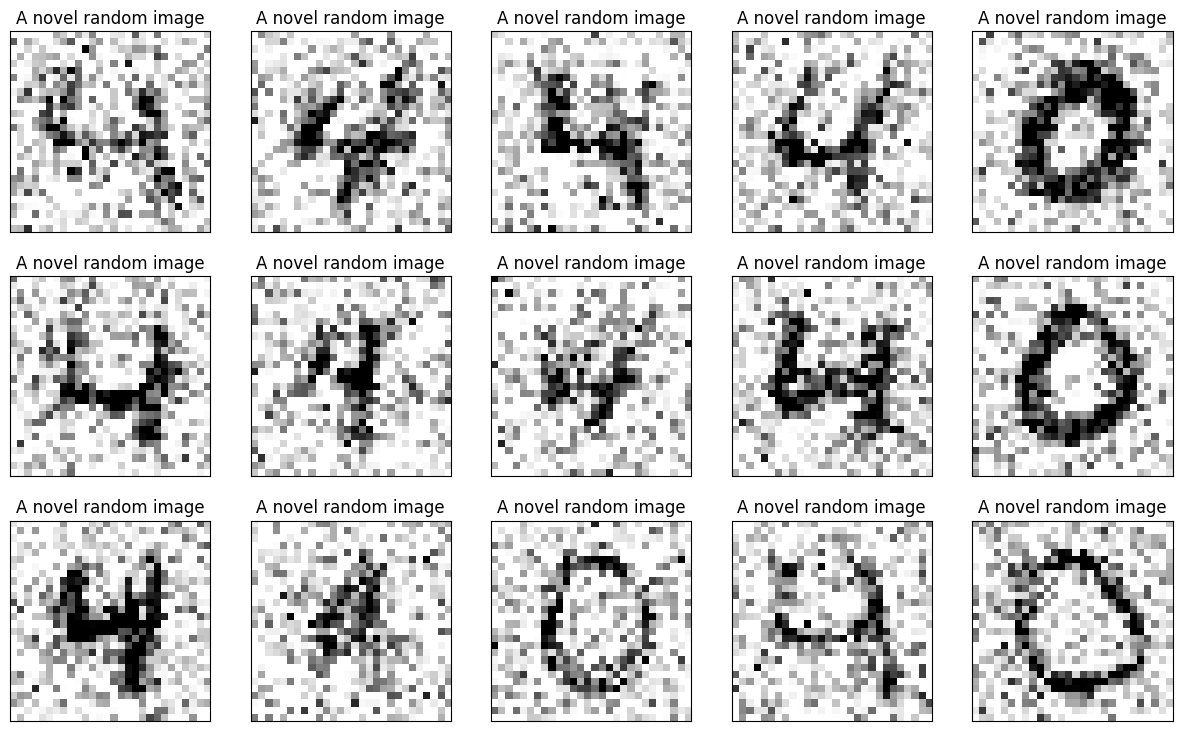

In [75]:
# Perform the k-means++ initialization
def doKMPPInitGreedy( X, C ):
    init = np.zeros( (C, X.shape[1]) )
    n = X.shape[0]
    # Choose a random data point and make it a centroid
    i = random.randint( 0, n-1 )
    init[0,:] = X[i,:]
    for t in range( 1, C ):
        # For all data points, find the squared Euclidean distance to the closest centroid
        # Python is funny: init[0,:] generates a vector but init[0:1,:] generates a matrix with one row :)
        dist = np.min( utils.getAllPairsDistances( X, init[0:t,:] ), axis = 1 )
        i = np.argmax( dist )
        init[t,:] = X[i,:]
    return init

def getSigmaInit( C, d ):
    iden = np.identity( d )
    init = np.zeros( (C, d, d) )
    for i in range( C ):
        init[i] = iden
    return init

# Obtain probability of data point x^i belonging to component N(\mu^c, S^c)
# The proper way of computing this is 1/\sqrt((2\pi)^d*|S^c|)*exp( - (x^i - \mu^c)'(S^c)^{-1}(x^i - \mu^c))
# However, this can be very expensive due to all the inverses involved
# Cheaper shortcut: approximate S^c by the identity matrix I_d
def doEStep(X, muVals, SigmaVals=None, piVals=None):
    """
    Simplified E-step using distance-based Gaussian approximation.
    Incorporates mixture weights π_k.
    X: (n, d)
    muVals: (K, d)
    piVals: (K,)
    Returns:
        qVals: (n, K) responsibilities
    """
    n, d = X.shape
    K = muVals.shape[0]
    if piVals is None:
        piVals = np.ones(K) / K  # Equal weights if not provided
    # Compute squared Euclidean distances between all X and means μ_k
    # utils.getAllPairsDistances returns (n, K) matrix of squared distances
    D2 = utils.getAllPairsDistances(X, muVals)  # shape (n, K)
    # Compute unnormalized posterior: π_k * exp(-0.5 * distance^2)
    qVals = piVals * np.exp(-0.5 * D2)  # broadcasting (n,K) * (K,)
    # Normalize over k to ensure ∑_k q_{nk} = 1
    rowSum = np.sum(qVals, axis=1, keepdims=True) + 1e-12
    qVals = qVals / rowSum
    return qVals

# Update the models by optimizing the Q function given by the E Step
# Ideally, both means and covariances for all components should be updated
# The solution to the weighted MLE for the covariance matrix update can be shown to be
# S^c = 1/Q_c * \sum_{i=1}^n q^i_c (x^i - \mu^c)(x^i - \mu^c)^T where Q_c = \sum_{i=1}^n q^i_c
# Cheaper shortcut: do not update covariance matrix at every M step (update only means every time)
# Update covariance only at the end (we are anyway not using SigmaVals to compute the E step)
def doMStep(X, qVals, prevMuVals, prevSigmaVals, eps=1e-1):
    """
    Performs the M-step for a Gaussian Mixture Model (GMM),
    updating mixture weights, means, and covariances.
    Implements the equations shown in your reference image:
        N_k     = sum_n γ_{nk}
        π_k     = N_k / N
        μ_k     = (1/N_k) sum_n γ_{nk} x_n
        Σ_k     = (1/N_k) sum_n γ_{nk} (x_n - μ_k)(x_n - μ_k)^T + εI
    Parameters
    ----------
    X : ndarray, shape (N, d)
        Data matrix, where each row is a data point x_n
    qVals : ndarray, shape (N, K)
        Responsibilities γ_{nk} from E-step
    prevMuVals : ndarray, shape (K, d)
        Previous means (used if a component has too few data points)
    prevSigmaVals : ndarray, shape (K, d, d)
        Previous covariances
    eps : float
        Small regularization constant for numerical stability
    Returns
    -------
    muVals : ndarray, shape (K, d)
        Updated mean vectors μ_k
    SigmaVals : ndarray, shape (K, d, d)
        Updated covariance matrices Σ_k
    piVals : ndarray, shape (K,)
        Updated mixture weights π_k
    """
    N, d = X.shape          # N = number of data points, d = features per sample
    K = qVals.shape[1]      # K = number of Gaussian components
    muVals = np.zeros((K, d))       # Means μ_k
    SigmaVals = np.zeros((K, d, d)) # Covariances Σ_k
    piVals = np.zeros(K)            # Mixture weights π_k
    # ---- Loop over each Gaussian component ----
    for k in range(K):
        # γ_{nk} → responsibilities for component k (shape: N,)
        gamma_k = qVals[:, k]
        # ---- Effective number of samples assigned to this component ----
        # N_k = Σ_n γ_{nk}
        N_k = np.sum(gamma_k)
        # ---- If this component has enough responsibility weight ----
        if N_k > 1:
            # ---- Mixture weight ----
            # π_k = N_k / N
            piVals[k] = N_k / N
            # ---- Mean ----
            # μ_k = (1/N_k) Σ_n γ_{nk} x_n
            muVals[k] = np.dot(gamma_k, X) / N_k
            # ---- Covariance ----
            # Σ_k = (1/N_k) Σ_n γ_{nk} (x_n - μ_k)(x_n - μ_k)^T + εI
            X_centered = X - muVals[k]  # (N, d)
            SigmaVals[k] = (X_centered.T @ (X_centered * gamma_k[:, np.newaxis])) / N_k
            SigmaVals[k] += eps * np.eye(d)  # regularization term
        else:
            # ---- If cluster nearly empty, retain old parameters ----
            muVals[k] = prevMuVals[k]
            SigmaVals[k] = prevSigmaVals[k]
            piVals[k] = 1.0 / K
    return muVals, SigmaVals, piVals

# Execute the EM algorithm for jointly learning a mixture of general (not standard) Gaussians
def doEMGMM( X, C, initMu, initSigma, niter ):
    muVals = initMu
    SigmaVals = initSigma
    piVals = np.ones(C) / C
    # Perform the EM algorithm for niter steps
    for t in range( niter ):
        qVals = doEStep( X, muVals, SigmaVals, piVals)
        (muVals, SigmaVals, piVals) = doMStep( X, qVals, muVals, SigmaVals )
    # Cheaper shortcut we employed -- doing costly S^c updates only once at the end
    return (muVals, SigmaVals, qVals, piVals)

# Number of components in the Gaussian mixture model (GMM)
C = 10
niter = 5

initMu = doKMPPInitGreedy( X, C )
initSigma = getSigmaInit( C, X.shape[1] )
(muVals, SigmaVals, qVals, piVals) = doEMGMM( X, C, initMu, initSigma, niter )
        
numRows = 2
numCols = C//2

# Visualize the means/modes of the various components the EM algorithm returned
# Notice how the various components do not just capture the different digits but also
# different ways/styles of writing each digit e.g. slanted 0 vs fat round 0 etc
fig7, axs7 = pd.getFigList( numRows, numCols )
labels = [ "Component number %s" % (i+1) for i in range( numRows * numCols ) ]
pd.showImagesNoAxes( axs7, muVals, numRows, numCols, resize = True, imShape = imShape, labelList = labels )

numRows = 3
numCols = 5

fig8, axs8 = pd.getFigList( numRows, numCols )
labels = [ "A novel random image" for i in range( numRows * numCols ) ]
randSamples = np.zeros( (numRows * numCols, d) )
for i in range( numRows * numCols ):
    # Choose a random component of the GMM from which to sample
    # It should be noted here that we have not used the label information in the data at all
    # All these results are being achieved in a completely "unsupervised" setting
    # Also note that all of these are novel images -- that never appeared in the training set
    # Notice the significantly improved quality of the novel images compared to previous attempts
    idx = random.randint( 0, C - 1 )
    randSamples[i] = rand.multivariate_normal( muVals[idx], SigmaVals[idx], check_valid = "raise" )

randSamples = truncatePixels( randSamples )
pd.showImagesNoAxes( axs8, randSamples, numRows, numCols, resize = True, imShape = imShape, labelList = labels )

**The importance of modelling covariances**: the covariance of a vector random variable tells us how two of its components vary together. For example, does one component always take a low value when the other one takes a high value, or do both take high and low values together, or are the components uncorrelated? We conduct a toy experiment to explicitly see this happening.

**Another Toy Dataset**: let us create another toy dataset of upright and inverted 7s. Notice that an upight 7 means that there are black pixels at the top-left, top-right, and bottom-right regions of the image. An inverted 7, on the other hand means that there are black pixels in the top-left, bottom-left, and bottom-right regions of the image.

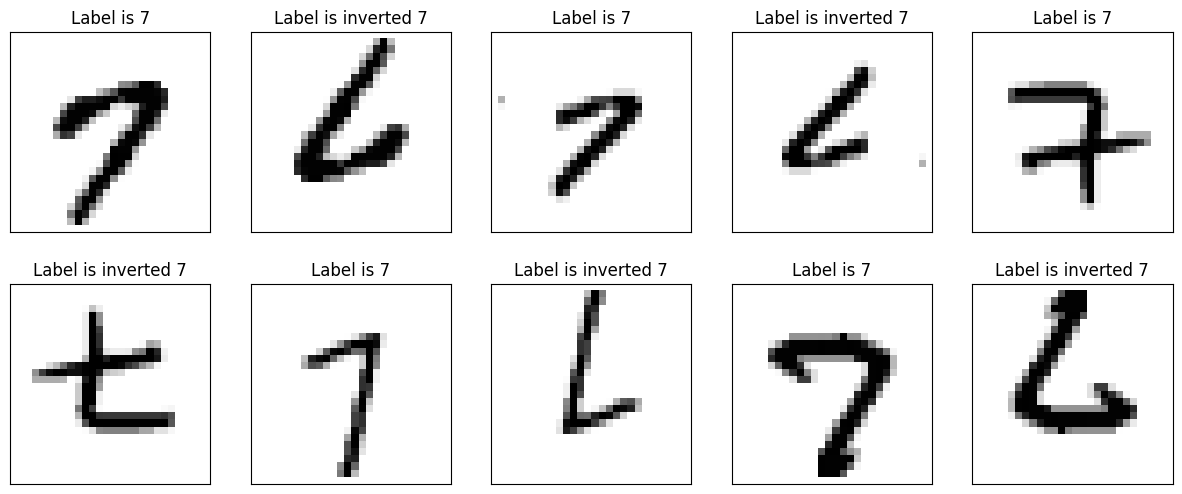

In [76]:
labels = np.array( [7] )
(X,y) = getDataSubset( labels )
Xinv = X[:,::-1,::-1]
n = X.shape[0]
d = np.prod( X.shape[1:] )
X = X.reshape( n, d )
Xinv = Xinv.reshape( n, d )

Xcomb = np.zeros( (2 * n, d) )
Xcomb[::2] = X
Xcomb[1::2] = Xinv

n = 2 * n

numRows = 2
numCols = 5

fig9, axs9 = pd.getFigList( numRows, numCols )
labels = [ "" for i in range( numRows * numCols ) ]
labels1 = [ "Label is %s" % y[i] for i in range( (numRows * numCols) // 2 ) ]
labels2 = [ "Label is inverted %s" % y[i] for i in range( (numRows * numCols) // 2 ) ]
labels[::2] = labels1
labels[1::2] = labels2

pd.showImagesNoAxes( axs9, Xcomb[:numRows*numCols], numRows, numCols, resize = True, imShape = imShape, labelList = labels )

Suppose we want to learn a single Gaussian (not a mixture) as a generative model to fit this dataset. Fitting a spherical Gaussian i.e. whose covariance matrix is a multiple of the identity matrix gives very poor samples since such a distribution is incapable of storing the fact that in this toy dataset, if there are black pixels in the top-right region, then the bottom-left region is largely vacant (since that would be an upright 7) and if there are black pixels in the bottom-left region, then the top-right region is largely vacant (since that would be an inverted 7). Only covariance among different pixels can allow a distribution to store such information about correlated behavior among pixels.

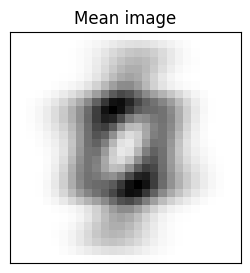

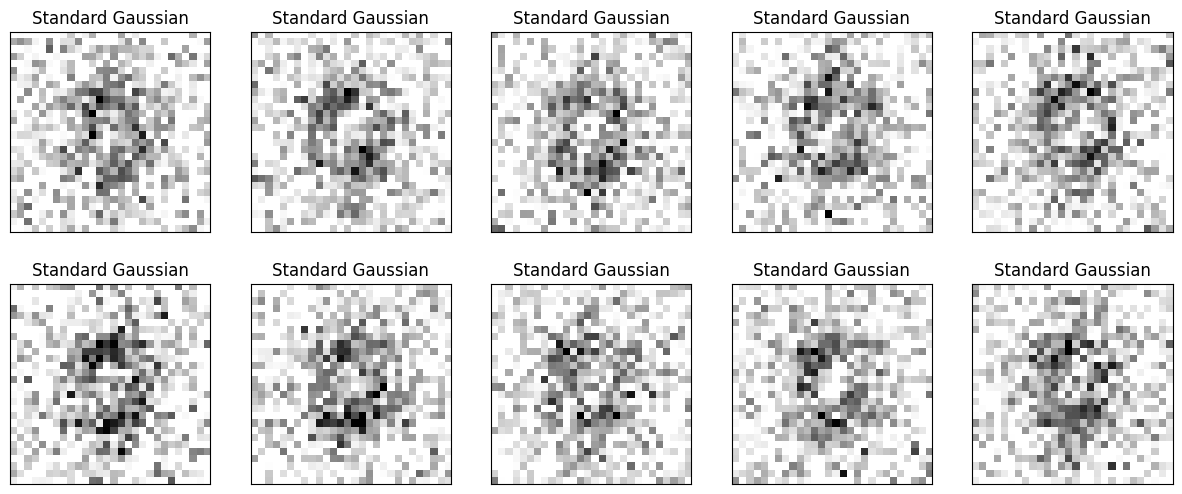

In [77]:
mu = fitSingleStandardGaussian( Xcomb )
sigmaSq = np.square( lin.norm( Xcomb - mu, 'fro' ) ) / (n * d)

fig10, axs10 = pd.getFigList( 1, 1 )
labels = [ "Mean image" ]
pd.showImagesNoAxes( axs10, mu[ np.newaxis, : ], 1, 1, resize = True, imShape = imShape, labelList = labels )

fig11, axs11 = pd.getFigList( numRows, numCols )
labels = [ "Standard Gaussian" for i in range( numRows * numCols ) ]
randSamples = rand.multivariate_normal( mu, sigmaSq*np.identity( d ), size = numRows * numCols, check_valid = "raise" )
randSamples = truncatePixels( randSamples )
pd.showImagesNoAxes( axs11, randSamples, numRows, numCols, resize = True, imShape = imShape, labelList = labels )

Using a proper Gaussian with a general covariance allows even a single Gaussian to capture the fact that there exist upright and inverted 7s in this dataset and give much better samples. Note that most of the samples are either clearly upright 7s or else clearly inverted 7s i.e. the distribution has learnt this fact about pixels in the top-right and bottom-left corner being anti-correlated in this dataset. Note that we did not need a mixture of 2 or more Gaussians to capture this behavior! Of course, learning a mixture of Gaussians would indeed give better results but be more expensive in terms of training time and model size too.

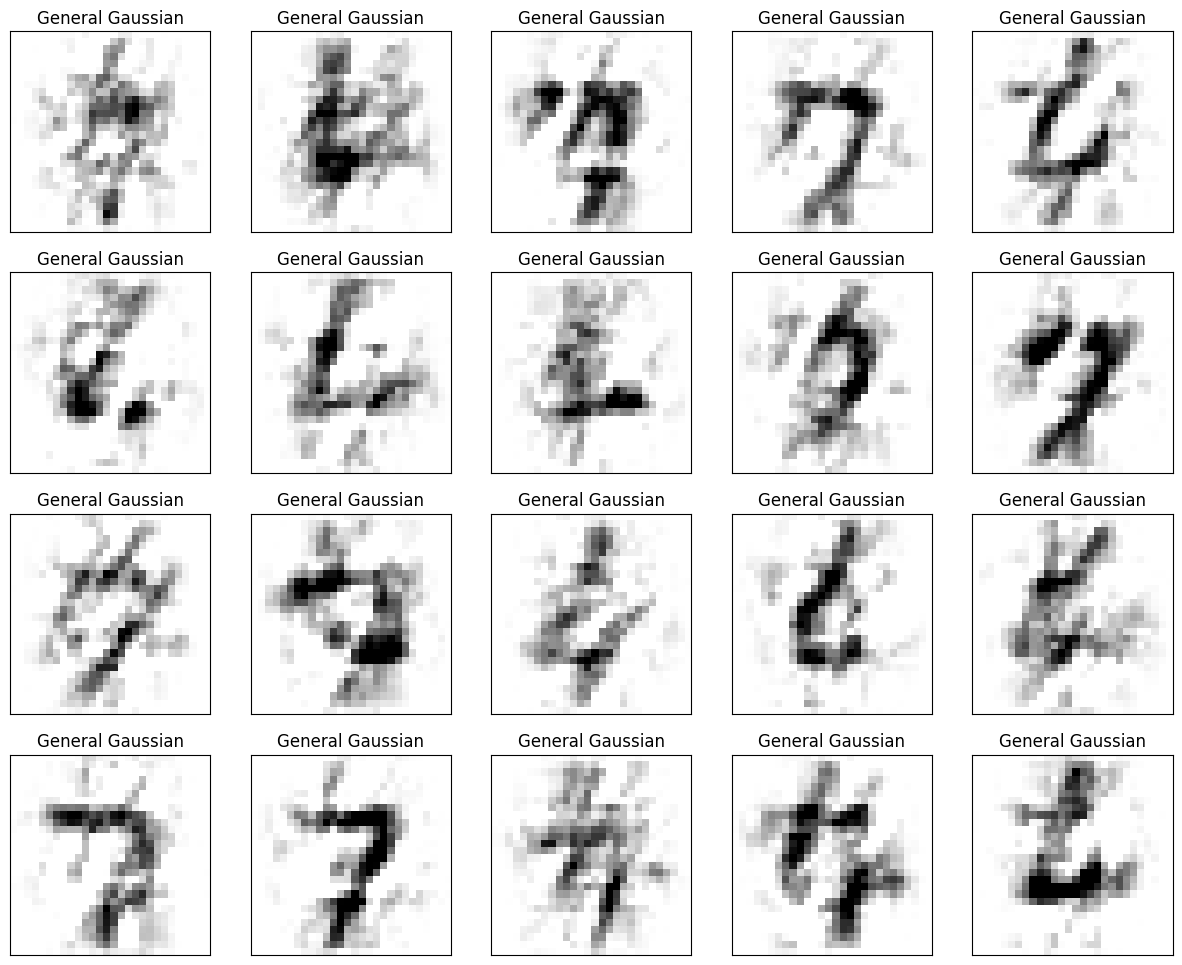

In [78]:
(mu, cov) = fitSingleGaussian( Xcomb )

numRows = 4
numCols = 5

fig12, axs12 = pd.getFigList( numRows, numCols )
labels = [ "General Gaussian" for i in range( numRows * numCols ) ]
randSamples = rand.multivariate_normal( mu, cov, size = numRows * numCols, check_valid = "raise" )
randSamples = truncatePixels( randSamples )
pd.showImagesNoAxes( axs12, randSamples, numRows, numCols, resize = True, imShape = imShape, labelList = labels )

**Classification using a Generative Model**: Generative models can not only generate new examples, they can also be used to classify data points as well. In the following, we take the full MNIST dataset (i.e. not just 0s or 4s or 7s) and learn a single Gaussian per class. Note that now we are indeed using the labels of the images i.e. we are no longer doing EM. We are simply learning the mean and covariance for 10 Gaussians, one corresponding to each of the classes {0, 1, ..., 9} in the dataset. This method gets an 85.73% prediction accuracy on the test dataset. This is decent although not very impressive. Using kernel SVMs, it is possible to get around 95% prediction accuracy and deep convolutional networks can drive this up to 99.9% and above. However, notice that this is an extremely simple generative model and yet it offers some decent prediction accuracy.

Prediction Accuracy:  0.9782


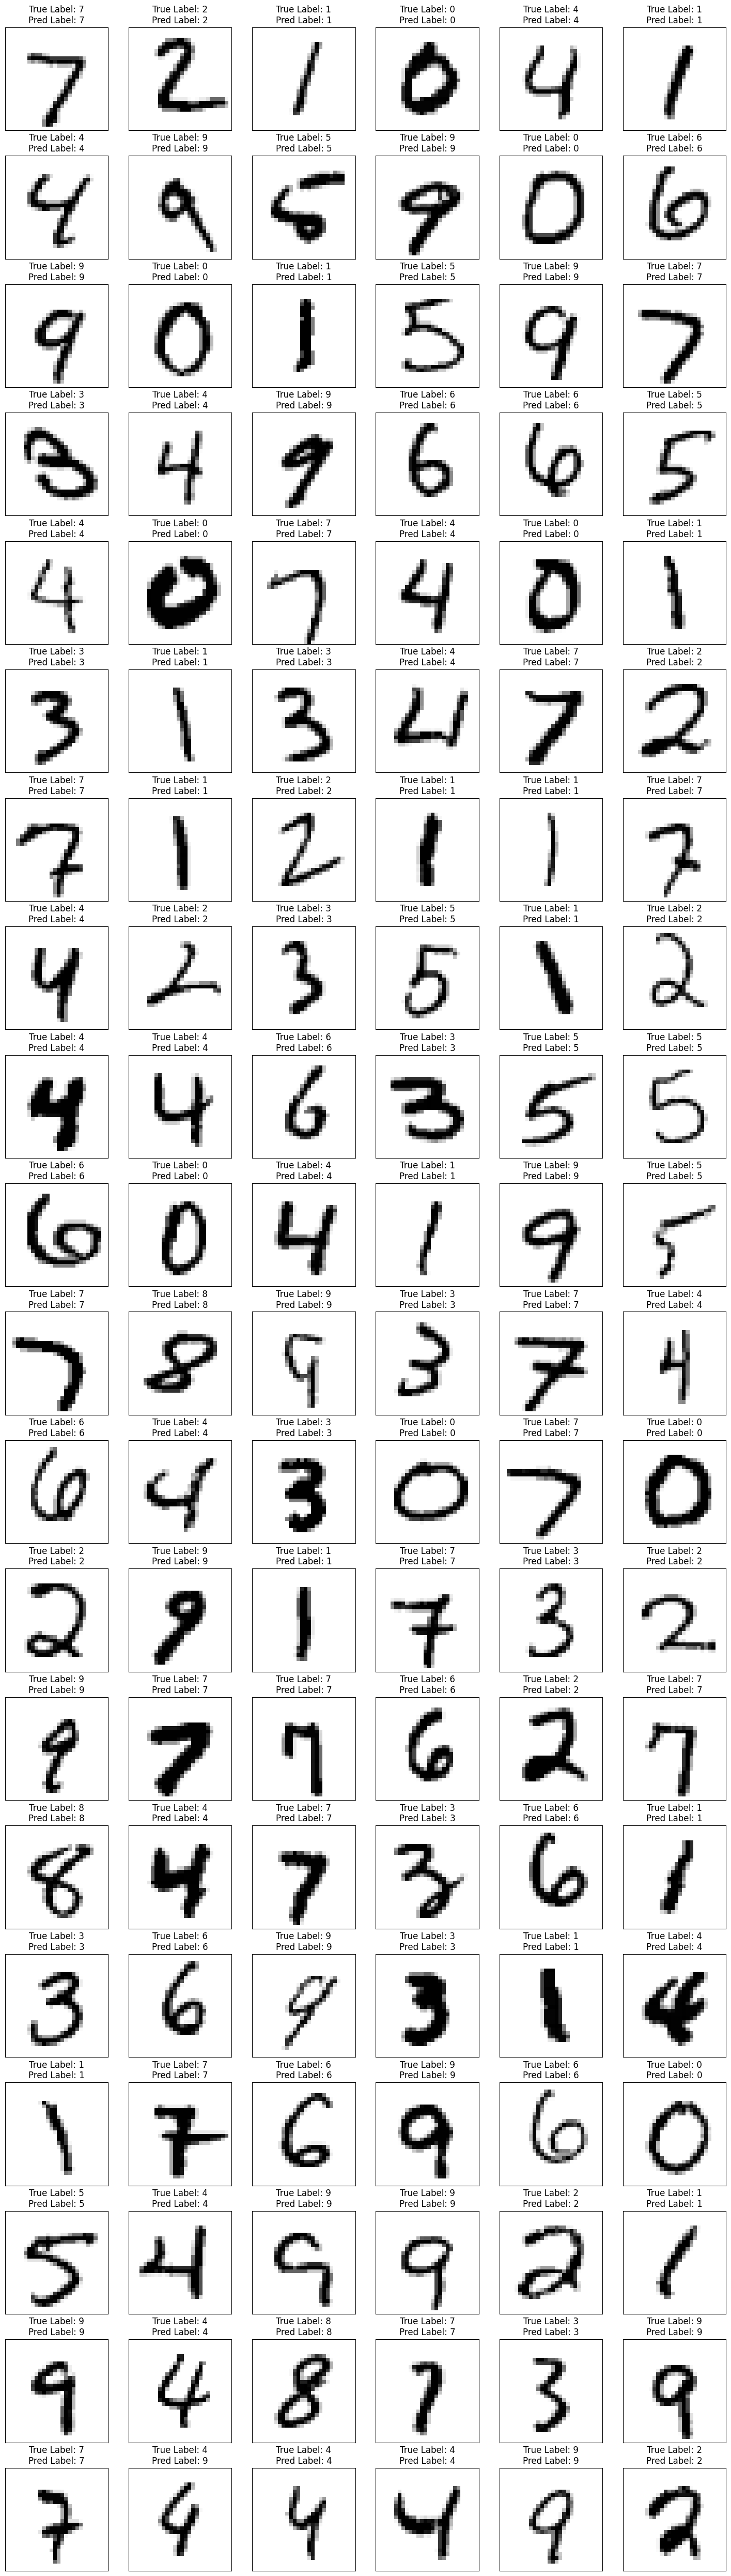

In [79]:
# Learn a single (general) Gaussian per class
def learnClassConditionalDist_GMM(X, y, K, niter=10):
    """
    Learn class-conditional Gaussian mixture models P(X | Y=c)
    using the EM algorithm for each class c.
    Each class is modeled as a mixture of K Gaussians.
    """
    labels, labelCounts = np.unique(y, return_counts=True)
    C = labels.size
    n, d = X.shape
    model = []
    for c in range(C):
        # Extract samples belonging to class c
        XThisLabel = X[y == c]
        # --- Initialize means and covariances ---
        initMu = doKMPPInitGreedy(XThisLabel, K)
        initSigma = getSigmaInit(K, XThisLabel.shape[1])
        # --- Run EM-GMM for this class ---
        muVals, SigmaVals, qVals, piVals = doEMGMM(
            XThisLabel, K, initMu, initSigma, niter
        )
        # --- Mixture weights (π_ck): one per component of class c ---
        # These should sum to 1 within each class
        pi = piVals / np.sum(piVals)
        # --- Class prior: P(Y=c) = (# samples of class c) / (total samples) ---
        prior_c = labelCounts[c] / n
        # --- Save the GMM model for this class ---
        # model[c] = (mu_k, Sigma_k, pi_k, class_label, prior)
        model.append((muVals, SigmaVals, pi, c, prior_c))
    return C, model

# Stretch out the 28 x 28 image into a 784 dimensional vector
def flattenTensor( X ):
    n = X.shape[0]
    d = np.prod( X.shape[1:] )
    return X.reshape( n, d )

def predictClassScores_GMM(X, muList, SigmaList, piList, p, mask=[]):
    """
    Compute log posterior scores log P(y=c | x)
    for a class modeled by a Gaussian Mixture Model (GMM).
    """
    if len(mask) == 0:
        mask = np.ones((X.shape[1],), dtype=bool)

    N = X.shape[0]
    K = len(piList)
    D = np.sum(mask)
    log_probs = np.zeros((N, K))

    for k in range(K):
        mu = muList[k]
        Sigma = SigmaList[k]
        pi = piList[k]

        XCent = X[:, mask] - mu[mask]
        SInv = lin.pinv(Sigma[mask, :][:, mask])
        (sign, logdet) = lin.slogdet(Sigma[mask, :][:, mask])
        SLogDet = logdet if sign > 0 else 0

        # Full Gaussian log probability with normalization term
        log_gauss = -0.5 * (
            D * np.log(2 * np.pi)
            + SLogDet
            + np.sum((XCent @ SInv) * XCent, axis=1)
        )

        # Add log mixture weight
        log_probs[:, k] = np.log(pi + 1e-12) + log_gauss

    # log-sum-exp trick for numerical stability
    max_log = np.max(log_probs, axis=1, keepdims=True)
    log_px_given_y = max_log + np.log(np.sum(np.exp(log_probs - max_log), axis=1, keepdims=True))

    # Add log class prior
    log_posterior = log_px_given_y.flatten() + np.log(p + 1e-12)

    return log_posterior


def predictGen_GMM(X, model, C, mask=[]):
    classScores = np.zeros((X.shape[0], C))
    for muList, SigmaList, piList, c, p in model:
        classScores[:, c] = predictClassScores_GMM(X, muList, SigmaList, piList, p, mask)
    return np.argmax(classScores, axis=1)

((XTrain, yTrain), (XTest, yTest)) = mnist_dataloader.load_data()
yTrain = np.array( yTrain )
yTest = np.array( yTest )

tmp = np.zeros( ( len( XTrain ), 28, 28 ) )
for i in range( len( XTrain )):
    tmp[ i, : ] = np.concatenate( XTrain[i] ).reshape( ( 28, 28 ) )
XTrain = tmp

tmp = np.zeros( ( len( XTest ), 28, 28 ) )
for i in range( len( XTest )):
    tmp[ i, : ] = np.concatenate( XTest[i] ).reshape( ( 28, 28 ) )
XTest = tmp

# Normalize data coordinates otherwise numbers in later calculations explode
# Also, flatten images for sake of convenience
imShape = XTrain.shape[1:]
XTrainFlat = flattenTensor( XTrain/256 )
XTestFlat = flattenTensor( XTest/256 )

K = 20  # number of Gaussians per class
(C, model) = learnClassConditionalDist_GMM(XTrainFlat, yTrain, K=K, niter=10)
yPred = predictGen_GMM(XTestFlat, model, C)

print( "Prediction Accuracy: ", sum(yPred == yTest)/yTest.size )

numRows = 20
numCols = 6

fig13, axs13 = pd.getFigList( numRows, numCols, sizey = 3.2 )
labels = ["True Label: %s\nPred Label: %s" % (yTest[i], yPred[i]) for i in range( numRows * numCols )]
pd.showImagesNoAxes( axs13, XTestFlat[:numRows*numCols], numRows, numCols, resize = True, imShape = imShape, labelList = labels )

In [80]:
# K_values = [1, 2, 3, 5, 10, 15, 20]

# train_accuracies = []
# test_accuracies = []

# for K in K_values:
#     print(f"\n=== Training GMMs with K = {K} components per class ===")
#     C, model = learnClassConditionalDist_GMM(XTrainFlat, yTrain, K=K, niter=10)
    
#     # Predictions on train and test sets
#     yTrainPred = predictGen_GMM(XTrainFlat, model, C)
#     yTestPred = predictGen_GMM(XTestFlat, model, C)
    
#     # Compute accuracies
#     train_acc = np.mean(yTrainPred == yTrain)
#     test_acc = np.mean(yTestPred == yTest)
    
#     train_accuracies.append(train_acc)
#     test_accuracies.append(test_acc)
    
#     print(f"K = {K}: Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}")

# # Plot accuracy curves
# plt.figure(figsize=(8, 5))
# plt.plot(K_values, train_accuracies, marker='o', label='Training Accuracy')
# plt.plot(K_values, test_accuracies, marker='s', label='Testing Accuracy')
# plt.title('Variation of Accuracy with K (Number of GMM Components per Class)')
# plt.xlabel('Number of Gaussian Components (K)')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.grid(True)
# plt.show()

**Classification in the presence of missing features**: a very nice property of generative models is that they allow us to perform classification on test points even those test points have missing features. Generative models can also function even if training data has missing features but those algorithms are more involved since they require the use of latent variables and some version of the EM algorithm to be executed.

Below we use the generative mode we trained above, to classify test images for whom a whole bunch of pixels have been removed or _censored_. We see that classification accuracy drops as more and more pixels are wiped out which is expected. What is interesting is that if we wipe out all pixels (we can do this by setting X[:, :, :] = 0 in the method censorImages() below), we get a prediction accuracy of around 11%. The reason for this is two-fold.
1. We will see that when all pixels are wiped out, the method always predicts the label of the image as 1. Since 1s constitute around 11% of the dataset, this explains the 11% accuracy since the method is technically correct on those images.
1. The reason why the method predicts 1 as the default label for a totally blank image has to do with the fact that the the label 1 is among the most popular in the dataset and so the class has high prior probability. Moreover, images of the digit 1 contain the most blank/white space so even in terms of likelihood, the label 1 wins when the image is completely blank.
1. The above two factors imply that the label 1 wins for a blank image.

In the following, we remove around 21% of the central portion of the test images. This causes prediction accuracy to drop to 78.57. However, given their generative capabilities, generative models are not just able to classify test data points with missing features, they are able to _impute_ or fill-in those missing features with reasonable values as well. Examples of such reconstructions are given below. Note that the reconstructions are decent although a bit blurry. This is all the more impressive when we look at the censored images which, to the human eye, seem to convey little information about the true image since the central portions are crucial in the images and those are exactly the pixels that got censored. Also notice that some of the misclassification are reasonable e.g. misclassifying a 9 as a 7 etc.

Prediction Accuracy on Censored Images:  0.8665


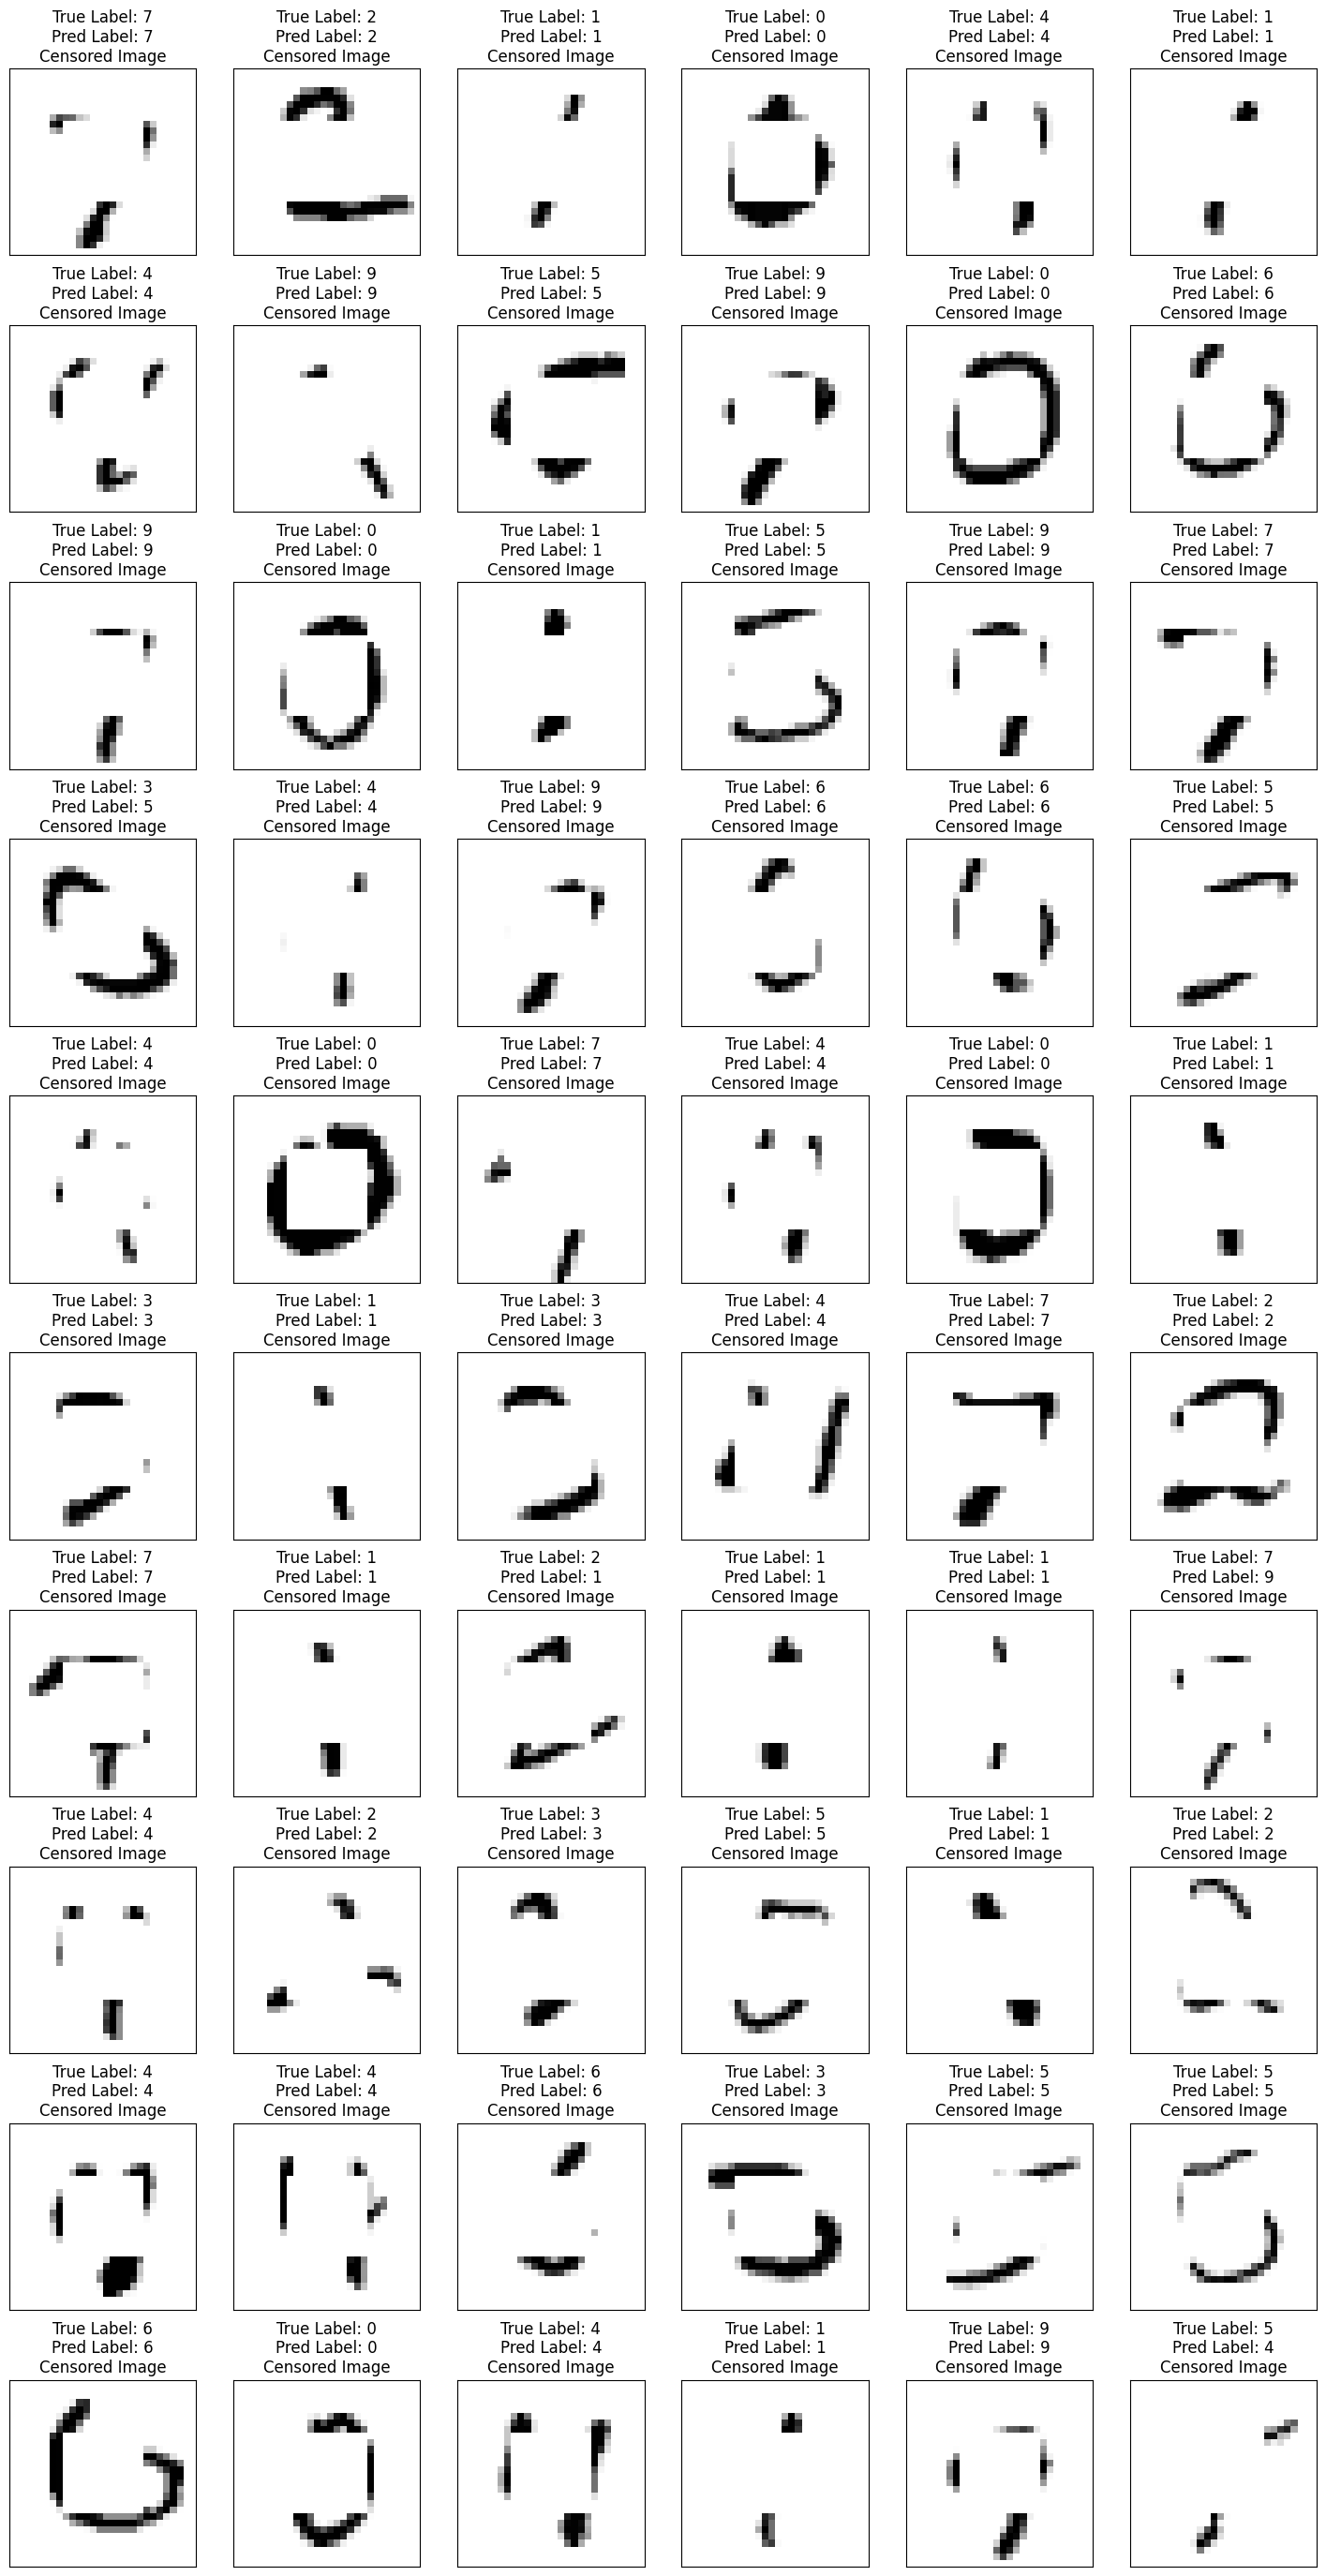

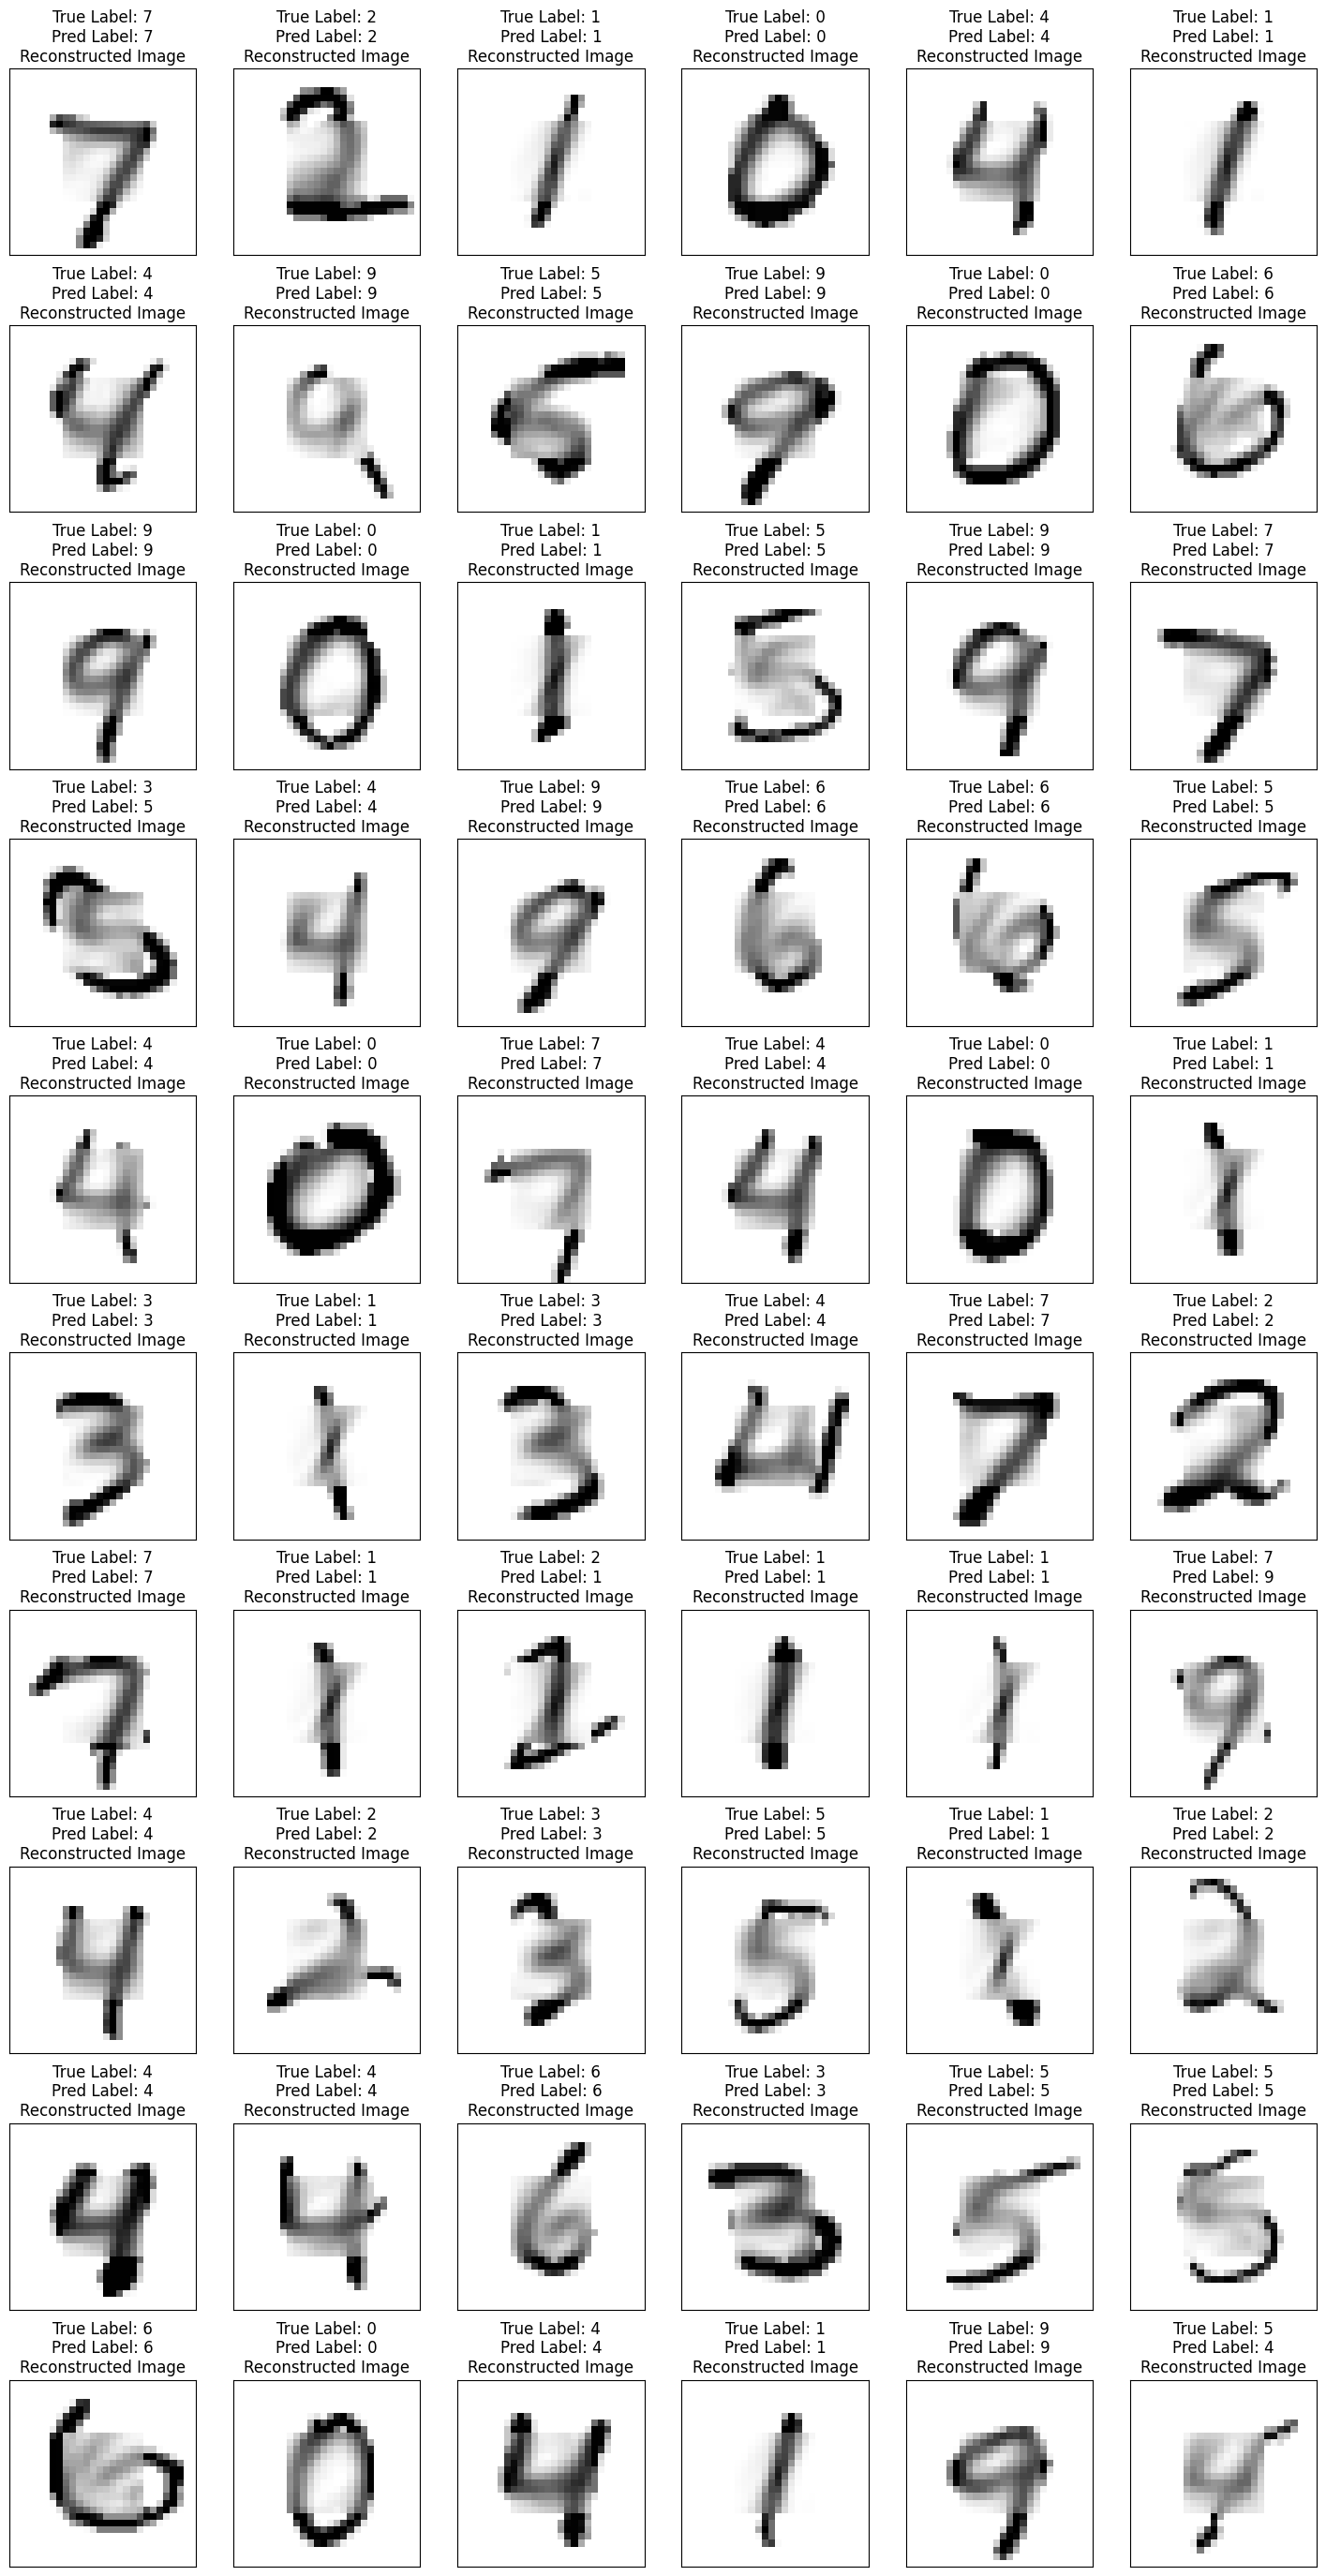

In [81]:
# You may try more aggressive censoring e.g. X[:, 5:20, 5:20] = 0 which wipes out around 28% of the pixels
# Accuracy will fall as we wipe out more and more pixels
def censorImages( X ):
    # Wipe out 21% of the pixels from the central part of the image
    X[:, 8:20, 8:20] = 0
    return X

# Make sure that reconstructed image does not have any negative-valued pixels
def truncatePixels( X, low = 0, high = 1 ):
    X[X < low] = low
    X[X > high] = high
    return X

# Reconstruct the image using the Gaussian conditionals
def reconstructImages(X, yPred, model, mask):
    """
    Reconstruct missing (censored) pixels using Gaussian mixture conditionals.
    Each class has a GMM; we use a weighted combination of all its components.
    """
    XRecon = np.zeros(X.shape)
    XRecon[:, mask] = X[:, mask]  # keep observed pixels

    for i in range(X.shape[0]):
        # Get predicted class's GMM parameters
        muList, SigmaList, piList, c, p = model[yPred[i]]

        recon_total = np.zeros(np.sum(~mask))
        weight_total = 0.0

        # Combine reconstructions from all mixture components
        for k in range(len(piList)):
            mu = muList[k]
            Sigma = SigmaList[k]

            recon_k = mu[~mask] + Sigma[~mask, :][:, mask].dot(
                lin.pinv(Sigma[mask, :][:, mask]).dot(XRecon[i, mask] - mu[mask])
            )

            recon_total += piList[k] * recon_k
            weight_total += piList[k]

        XRecon[i, ~mask] = recon_total / (weight_total + 1e-12)

    return truncatePixels(XRecon)

((XTrain, yTrain), (XTest, yTest)) = mnist_dataloader.load_data()
yTrain = np.array( yTrain )
yTest = np.array( yTest )

tmp = np.zeros( ( len( XTrain ), 28, 28 ) )
for i in range( len( XTrain )):
    tmp[ i, : ] = np.concatenate( XTrain[i] ).reshape( ( 28, 28 ) )
XTrain = tmp

tmp = np.zeros( ( len( XTest ), 28, 28 ) )
for i in range( len( XTest )):
    tmp[ i, : ] = np.concatenate( XTest[i] ).reshape( ( 28, 28 ) )
XTest = tmp

XTestCensorFlat = flattenTensor( censorImages( XTest ) / 256 )
mask = flattenTensor( censorImages( np.ones( imShape )[np.newaxis, :] ) )[0] == 1

yPred = predictGen_GMM(XTestCensorFlat, model, C, mask)

print( "Prediction Accuracy on Censored Images: ", sum(yPred == yTest)/yTest.size )

numRows = 10
numCols = 6

XTestReconFlat = reconstructImages( XTestCensorFlat[:numRows*numCols], yPred[:numRows*numCols], model, mask )

fig14, axs14 = pd.getFigList( numRows, numCols, sizey = 3.5 )
labels = ["True Label: %s\nPred Label: %s\nCensored Image" % (yTest[i], yPred[i]) for i in range( numRows * numCols )]
pd.showImagesNoAxes( axs14, XTestCensorFlat[:numRows*numCols], numRows, numCols, resize = True, imShape = imShape, labelList = labels )

fig15, axs15 = pd.getFigList( numRows, numCols, sizey = 3.5 )
labels = ["True Label: %s\nPred Label: %s\nReconstructed Image" % (yTest[i], yPred[i]) for i in range( numRows * numCols )]
pd.showImagesNoAxes( axs15, XTestReconFlat[:numRows*numCols], numRows, numCols, resize = True, imShape = imShape, labelList = labels )

In [82]:
K_values = [1, 2, 3, 5, 10, 15, 20]

test_accuracies = []

for K in K_values:
    print(f"\n=== Training GMMs with K = {K} components per class ===")
    
    # Train class-conditional GMMs for each digit
    C, model = learnClassConditionalDist_GMM(XTrainFlat, yTrain, K=K, niter=10)
    
    # Predict only on censored test set
    yPred = predictGen_GMM(XTestCensorFlat, model, C, mask)
    
    # Compute accuracy
    acc = np.sum(yPred == yTest) / yTest.size
    test_accuracies.append(acc)
    
    print(f"Prediction Accuracy on Censored Images for K={K}: {acc:.4f}")

# --- Plot accuracy vs K ---
plt.figure(figsize=(8, 5))
plt.plot(K_values, test_accuracies, marker='s', label='Testing Accuracy on Censored Images')
plt.title('Accuracy vs Number of GMM Components per Class (K)')
plt.xlabel('Number of Gaussian Components (K)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


=== Training GMMs with K = 1 components per class ===
Prediction Accuracy on Censored Images for K=1: 0.8001

=== Training GMMs with K = 2 components per class ===
Prediction Accuracy on Censored Images for K=2: 0.8083

=== Training GMMs with K = 3 components per class ===
Prediction Accuracy on Censored Images for K=3: 0.8386

=== Training GMMs with K = 5 components per class ===
Prediction Accuracy on Censored Images for K=5: 0.8415

=== Training GMMs with K = 10 components per class ===
Prediction Accuracy on Censored Images for K=10: 0.8580

=== Training GMMs with K = 15 components per class ===


KeyboardInterrupt: 